Explained variance ratio: [0.72770452 0.23030523]


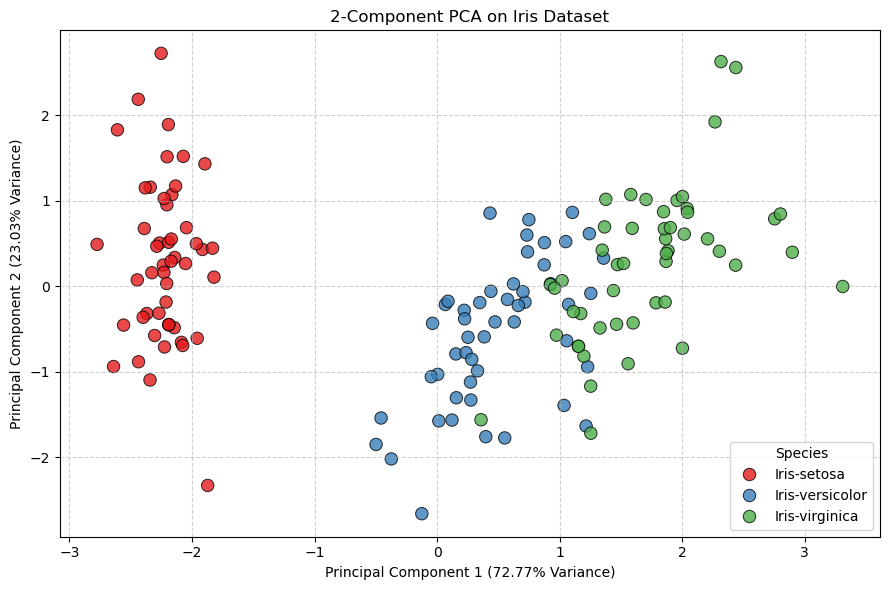

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('Iris.csv')

# Extract features
feature_cols = [col for col in df.columns if col not in ['Id', 'Species', 'Cluster']]
x = df.loc[:, feature_cols].values

# Standardizing the features (crucial for PCA)
x = StandardScaler().fit_transform(x)

# Applying PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Re-attach 'Species' if available for visualization, else use 'Cluster' if previously saved, or none
if 'Species' in df.columns:
    final_df = pd.concat([pca_df, df[['Species']]], axis=1)
    hue_col = 'Species'
else:
    final_df = pca_df
    hue_col = None

# Plotting the PCA
plt.figure(figsize=(9, 6))
if hue_col:
    sns.scatterplot(x='PC1', y='PC2', hue=hue_col, data=final_df, palette='Set1', s=80, edgecolor='k', alpha=0.8)
else:
    sns.scatterplot(x='PC1', y='PC2', data=final_df, color='b', s=80, edgecolor='k', alpha=0.8)

plt.title('2-Component PCA on Iris Dataset')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('pca_iris.png')
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")